# Exploratory Data Analysis - Ad Click Fraud Detection

This notebook explores the validated two-hour development dataset.

Main goals:

- understand the rare target class;
- study click and attribution patterns;
- compare apps, channels, devices, operating systems and IPs;
- check repeated-click behaviour;
- prepare a chronological validation strategy.

> **Target meaning:** `is_attributed = 1` means an app download was attributed to the click. It is not a confirmed fraud label. `attributed_time` is used only for data-quality checks because it occurs after the click.

## 1. Setup and data loading

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

TARGET = "is_attributed"
MODEL_COLUMNS = ["ip", "app", "device", "os", "channel", "click_time"]
CATEGORICAL_COLUMNS = ["ip", "app", "device", "os", "channel"]
VALIDATION_START = pd.Timestamp("2017-11-07 14:30:00")

In [ ]:
# This works when the notebook is opened from the notebooks folder
# Connecting paths

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "development_clicks.parquet"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

Loaded: d:\Projects\Ad_Click_Fraud_Detection\data\interim\development_clicks.parquet
Shape: (6397036, 8)


## 2. Dataset validation

In [3]:
display(df.head())

print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])
print("Start time:", df["click_time"].min())
print("End time:", df["click_time"].max())
print("Chronologically sorted:", df["click_time"].is_monotonic_increasing)

memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage: {memory_mb:.2f} MB")

,ip,app,device,os,channel,click_time,attributed_time,is_attributed
0,94118,3,1,8,280,2017-11-07 13:00:00,NaT,0
1,166410,3,2,58,135,2017-11-07 13:00:00,NaT,0
2,36823,3,1,19,442,2017-11-07 13:00:00,NaT,0
3,9460,21,1,25,128,2017-11-07 13:00:00,NaT,0
4,31784,2,1,19,469,2017-11-07 13:00:00,NaT,0


Rows: 6,397,036
Columns: 8
Start time: 2017-11-07 13:00:00
End time: 2017-11-07 14:59:59
Chronologically sorted: True
Memory usage: 176.92 MB


In [ ]:
# Missing Values Summary Report
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean().mul(100),
})

display(missing_summary.round(3))

attribution_time_check = pd.crosstab(
    df[TARGET],
    df["attributed_time"].isna(),
)

display(attribution_time_check)

,missing_count,missing_percentage
ip,0,0.000
app,0,0.000
device,0,0.000
os,0,0.000
channel,0,0.000
click_time,0,0.000
attributed_time,6381261,99.753
is_attributed,0,0.000


attributed_time,False,True
is_attributed,,
0,0,6381261
1,15775,0


**Insight:** The predictor columns have no missing values. `attributed_time` is missing only when the click was not attributed. This is expected, but the column must not be used for modelling.

In [ ]:
# Duplicate Rows Count
duplicate_rows = int(df.duplicated().sum())

predictor_duplicate_rows = int(
    df.duplicated(
        subset=MODEL_COLUMNS,
        keep=False,
    ).sum()
)

print("Complete duplicate rows:", f"{duplicate_rows:,}")

print(
    "Rows sharing the same predictor values:",
    f"{predictor_duplicate_rows:,}",
)

Complete duplicate rows: 97,011
Rows sharing the same predictor values: 188,630


**Insight:** Repeated rows are retained. Repeated clicks may be useful behaviour and are not automatically errors or fraud.

## 3. Target distribution and class imbalance

In [25]:
# Measure class imbalance

class_counts = (
  df[TARGET].
  value_counts()
  .sort_index()
)

class_percentages = (
  df[TARGET]
  .value_counts(normalize=True)
  .sort_index() * 100
)

class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages,
})

class_summary.index = ["Not attributed", "Attributed"]

display(class_summary.style.format({
    "count": "{:,.0f}",
    "percentage": "{:.6f}%",
}))

ratio = class_counts.loc[0] / class_counts.loc[1]
print(f"Negative-to-positive ratio: {ratio:.1f} to 1")

,count,percentage
Not attributed,"6,381,261",99.753401%
Attributed,"15,775",0.246599%


Negative-to-positive ratio: 404.5 to 1


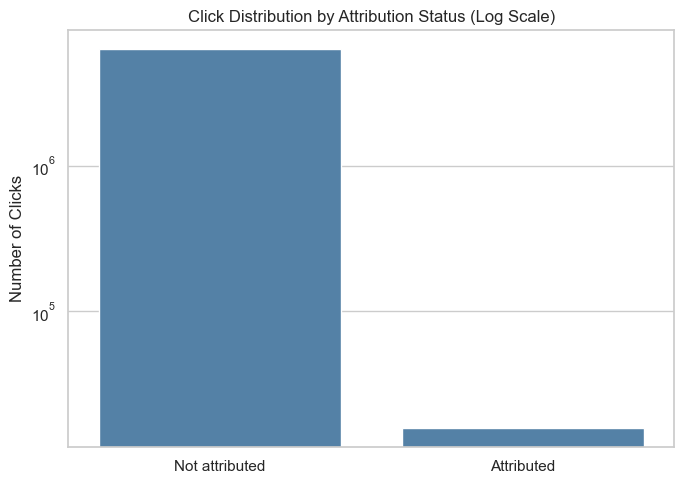

In [26]:
# Class imbalance visualization

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=class_summary.index,
    y=class_summary["count"],
    color="steelblue",
)

# scale adjust because +ve bar (1) is extremely small
ax.set_yscale("log")
ax.set_title("Click Distribution by Attribution Status (Log Scale)")
ax.set_xlabel("")
ax.set_ylabel("Number of Clicks")

plt.tight_layout()
plt.show()

**Insight:** Only about 0.25% of clicks are attributed. Accuracy alone would be misleading, so later modelling should focus on precision, recall and PR-AUC.

## 4. Chronological training and validation split

In [ ]:
# This section divides the two-hour dataset into an earlier training period and a later validation period.
# It answers:
# whether we can train the model using past clicks and evaluate it on future clicks without mixing the two periods.

train_mask = df["click_time"] < VALIDATION_START

# attributed_time is intentionally excluded
train_df = (
  df.loc[train_mask, MODEL_COLUMNS + [TARGET]]
)

validation_df = (
  df.loc[~train_mask, MODEL_COLUMNS + [TARGET]]
)

split_summary = pd.DataFrame(
  {
    "rows": [len(train_df), len(validation_df)],
    "attributed_clicks": [
        int(train_df[TARGET].sum()),
        int(validation_df[TARGET].sum()),
    ],
    "attribution_rate": [
        train_df[TARGET].mean() * 100,
        validation_df[TARGET].mean() * 100,
    ],
}, index=["Training", "Validation"]
)

display(split_summary.style.format({
    "rows": "{:,.0f}",
    "attributed_clicks": "{:,.0f}",
    "attribution_rate": "{:.6f}%",
}))

assert train_df["click_time"].max() < validation_df["click_time"].min()

,rows,attributed_clicks,attribution_rate
Training,"4,866,118","12,689",0.260762%
Validation,"1,530,918","3,086",0.201578%


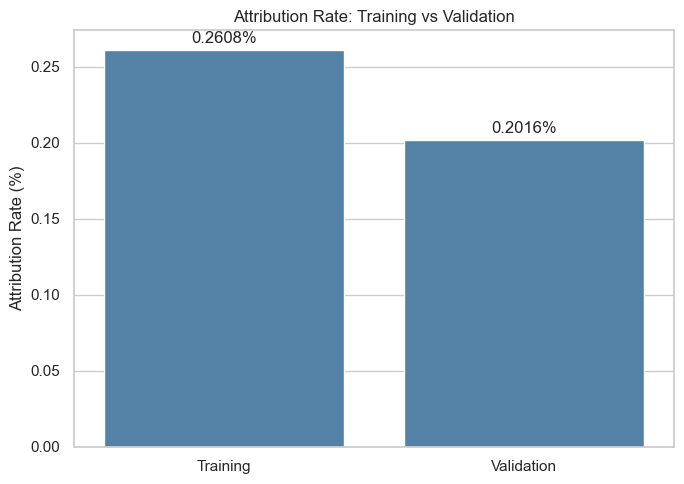

In [28]:
# Attribution rate comparison between training and validation data

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=split_summary.index,
    y=split_summary["attribution_rate"],
    color="steelblue",
)

ax.set_title("Attribution Rate: Training vs Validation")
ax.set_xlabel("")
ax.set_ylabel("Attribution Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f%%", padding=3)

plt.tight_layout()
plt.show()

**Insight:** Earlier clicks are used for training and later clicks for validation. The lower validation rate shows that behaviour changes over time.

## 5. Click and attribution patterns over time

In [30]:
# Aggregate by five-minute interval for better understanding

five_minute_bin = (
  df["click_time"]
  .dt.floor("5min")
  .rename("five_minute_bin")
)

time_summary = (
    df.groupby(five_minute_bin, observed=True)
    .agg(
        clicks=(TARGET, "size"),
        attributed_clicks=(TARGET, "sum"),
    )
    .reset_index()
)

time_summary["attribution_rate"] = (
    time_summary["attributed_clicks"]
    / time_summary["clicks"]
    * 100
)

display(time_summary.head())

,five_minute_bin,clicks,attributed_clicks,attribution_rate
0,2017-11-07 13:00:00,272758,736,0.269836
1,2017-11-07 13:05:00,262512,733,0.279225
2,2017-11-07 13:10:00,257092,716,0.278500
3,2017-11-07 13:15:00,262893,759,0.288711
4,2017-11-07 13:20:00,267419,748,0.279711


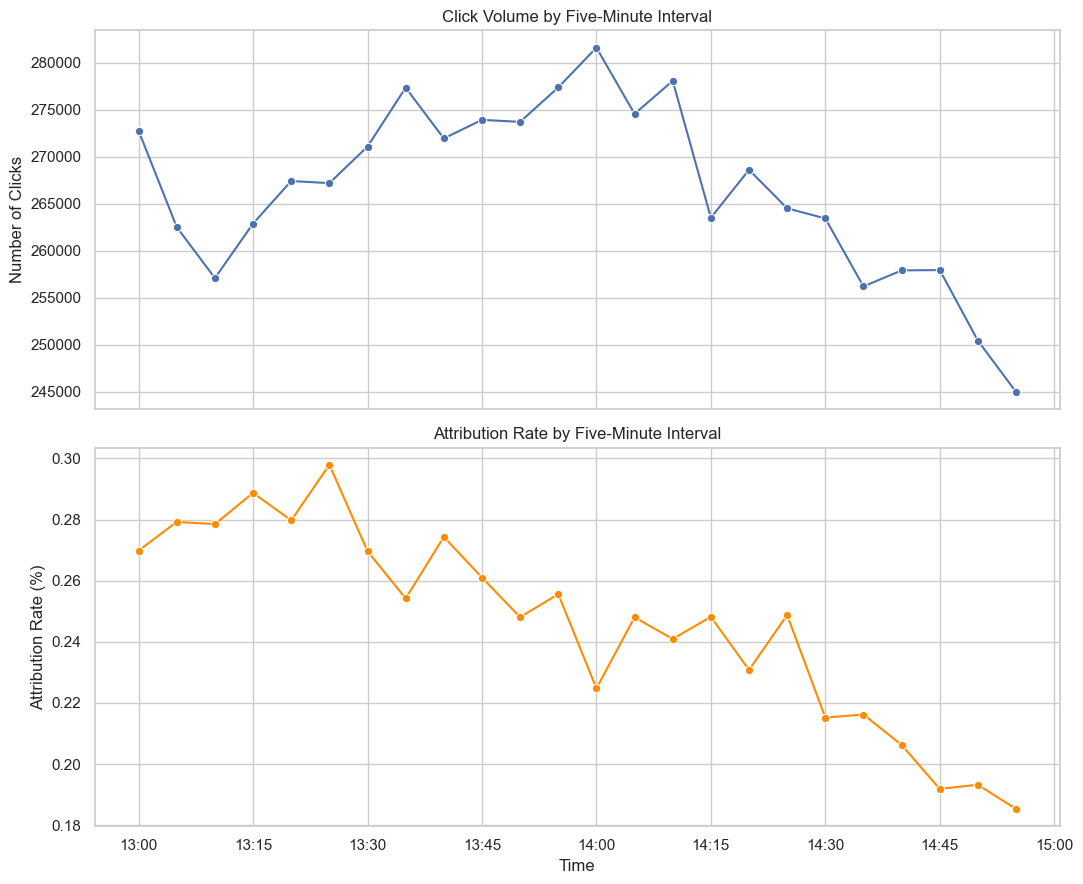

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

# Vis 1: Click Volume
sns.lineplot(
    data=time_summary,
    x="five_minute_bin",
    y="clicks",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Click Volume by Five-Minute Interval")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Clicks")

# Vis 2: Attribution Rate
sns.lineplot(
    data=time_summary,
    x="five_minute_bin",
    y="attribution_rate",
    marker="o",
    color="darkorange",
    ax=axes[1],
)
axes[1].set_title("Attribution Rate by Five-Minute Interval")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Attribution Rate (%)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

In [34]:
# Overall summary of time intervals ( Five minutes intervals )

time_range_summary = pd.Series(
    {
    "first_interval_rate": time_summary.iloc[0]["attribution_rate"],
    "last_interval_rate": time_summary.iloc[-1]["attribution_rate"],
    "minimum_interval_rate": time_summary["attribution_rate"].min(),
    "maximum_interval_rate": time_summary["attribution_rate"].max(),
    }
)

display(
  time_range_summary
  .to_frame("percentage")
  .style.format("{:.4f}%")
)

,percentage
first_interval_rate,0.2698%
last_interval_rate,0.1853%
minimum_interval_rate,0.1853%
maximum_interval_rate,0.2979%


**Insight:** Traffic and attribution rates change within the two-hour window. Values such as `0.27` on the rate chart mean **0.27%**, not 27%. This short window suggests that time features are worth testing, but it cannot prove a general time-of-day pattern.

## 6. Feature cardinality

,unique_values
ip,63208
device,869
app,341
os,241
channel,170


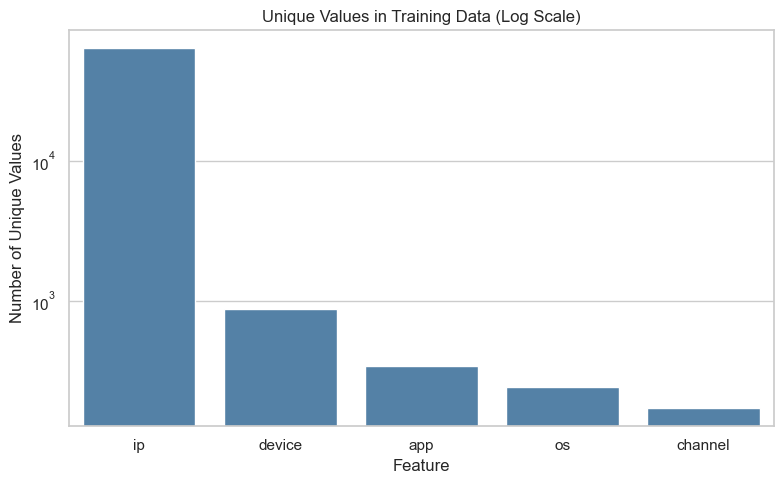

In [35]:
# Feature cardinality calculation

cardinality = (
    train_df[CATEGORICAL_COLUMNS]
    .nunique()
    .sort_values(ascending=False)
    .rename("unique_values")
    .to_frame()
)

display(cardinality)

# Category visualization

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=cardinality.reset_index(),
    x="index",
    y="unique_values",
    color="steelblue",
)
ax.set_yscale("log")
ax.set_title("Unique Values in Training Data (Log Scale)")
ax.set_xlabel("Feature")
ax.set_ylabel("Number of Unique Values")

plt.tight_layout()
plt.show()

**Insight:** `ip` has the highest cardinality. Dense one-hot encoding would be inefficient. Count features or models with categorical support are better choices.

## 7. App, channel, device and OS analysis

In [ ]:
# ======== Summarization for each categories ===================================================

# summarisation function
def create_category_summary(data, column):
    summary = (
        data.groupby(column, observed=True)
        .agg(
            clicks=(TARGET, "size"),
            attributed_clicks=(TARGET, "sum"),
            attribution_rate=(TARGET, "mean"),
        )
        .reset_index()
    )

    summary["attribution_rate"] *= 100
    summary["traffic_share"] = summary["clicks"] / len(data) * 100
    return summary


# 'plot function' for summarised categories
def plot_top_categories(summary, column, min_clicks, top_n=15):
    reliable = summary.loc[summary["clicks"] >= min_clicks]
    top = reliable.nlargest(top_n, "clicks").copy()
    top[column] = top[column].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.barplot(
        data=top,
        x=column,
        y="clicks",
        color="steelblue",
        ax=axes[0],
    )
    axes[0].set_title(f"Top {column.title()} IDs by Click Volume")
    axes[0].set_xlabel(f"{column.title()} ID")
    axes[0].set_ylabel("Number of Clicks")
    axes[0].tick_params(axis="x", rotation=45)

    sns.barplot(
        data=top,
        x=column,
        y="attribution_rate",
        color="darkorange",
        ax=axes[1],
    )
    axes[1].axhline(
        train_df[TARGET].mean() * 100,
        color="red",
        linestyle="--",
        label="Training average",
    )
    axes[1].set_title(
        f"Attribution Rate Among Top-Volume {column.title()} IDs"
    )
    axes[1].set_xlabel(f"{column.title()} ID")
    axes[1].set_ylabel("Attribution Rate (%)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return top

### Apps

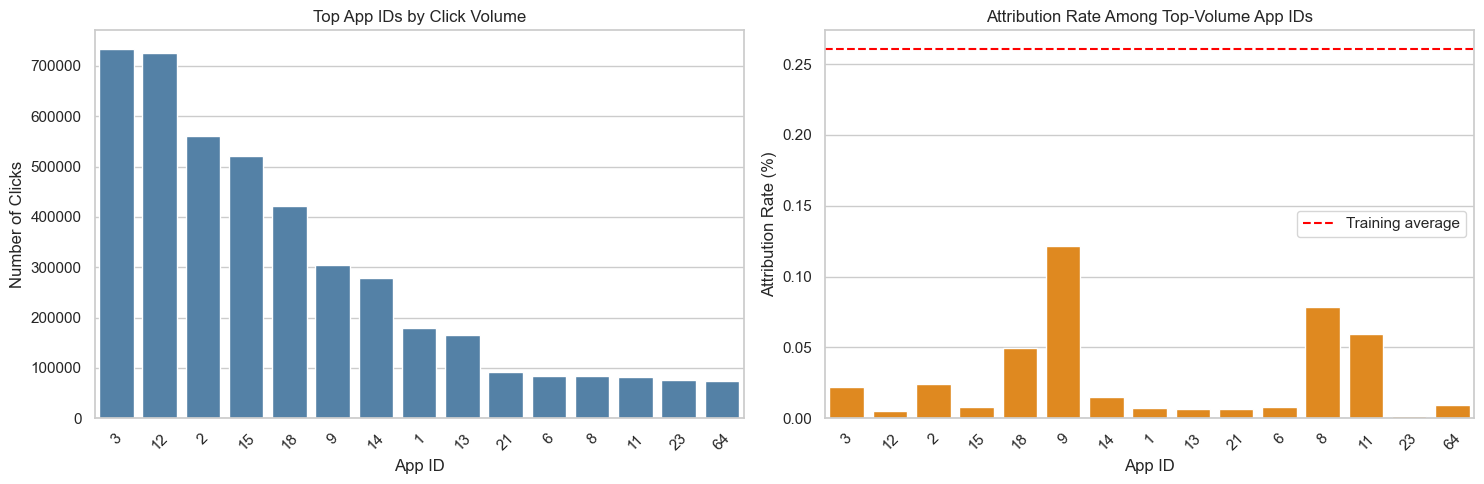

,app,clicks,attributed_clicks,attribution_rate
3,3,"733,546",162,0.0221%
12,12,"724,516",37,0.0051%
2,2,"560,984",135,0.0241%
15,15,"521,802",43,0.0082%
18,18,"421,753",209,0.0496%
9,9,"304,870",370,0.1214%
14,14,"277,714",41,0.0148%
1,1,"179,296",13,0.0073%
13,13,"166,409",11,0.0066%
21,21,"91,016",6,0.0066%


In [15]:
app_summary = create_category_summary(train_df, "app")
top_apps = plot_top_categories(app_summary, "app", min_clicks=5_000)

display(
    top_apps[["app", "clicks", "attributed_clicks", "attribution_rate"]]
    .style.format({
        "clicks": "{:,.0f}",
        "attributed_clicks": "{:,.0f}",
        "attribution_rate": "{:.4f}%",
    })
)

**Insight:** High click volume does not always produce a high attribution rate. App IDs are categories, not numeric measurements.

### Channels

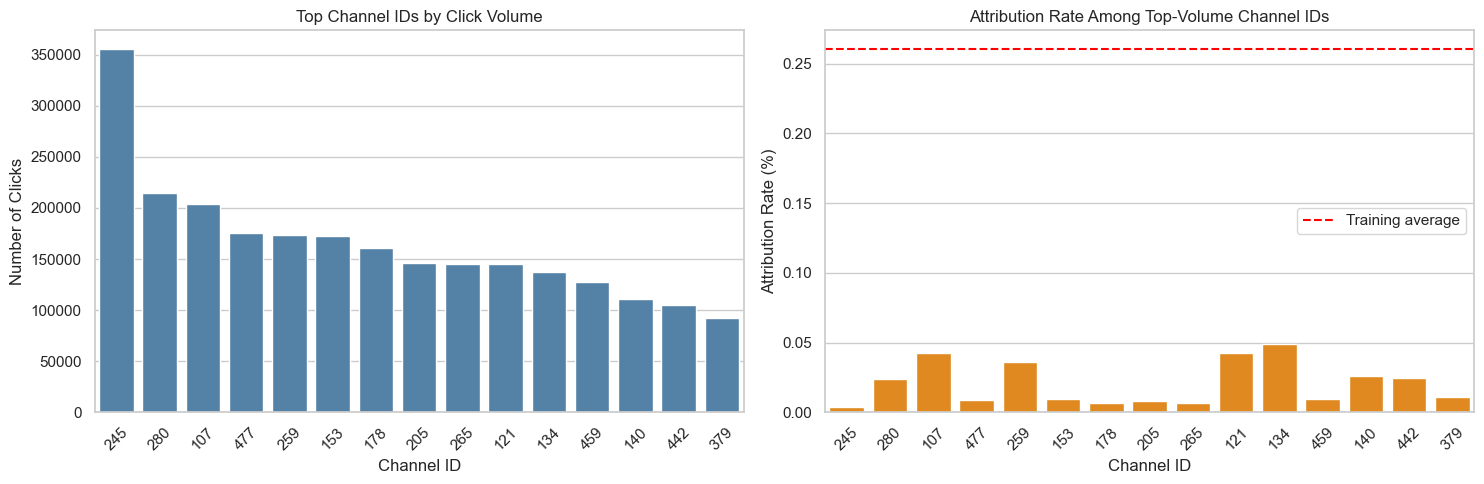

,channel,clicks,attributed_clicks,attribution_rate
71,245,"355,967",14,0.0039%
84,280,"214,949",51,0.0237%
15,107,"204,115",87,0.0426%
156,477,"175,312",15,0.0086%
75,259,"173,141",62,0.0358%
40,153,"172,538",16,0.0093%
46,178,"160,390",11,0.0069%
50,205,"146,447",12,0.0082%
77,265,"144,821",10,0.0069%
25,121,"144,806",62,0.0428%


In [16]:
channel_summary = create_category_summary(train_df, "channel")
top_channels = plot_top_categories(
    channel_summary,
    "channel",
    min_clicks=5_000,
)

display(
    top_channels[["channel", "clicks", "attributed_clicks", "attribution_rate"]]
    .style.format({
        "clicks": "{:,.0f}",
        "attributed_clicks": "{:,.0f}",
        "attribution_rate": "{:.4f}%",
    })
)

**Insight:** Attribution performance differs across advertising channels, so `channel` may be useful for prediction.

### Devices

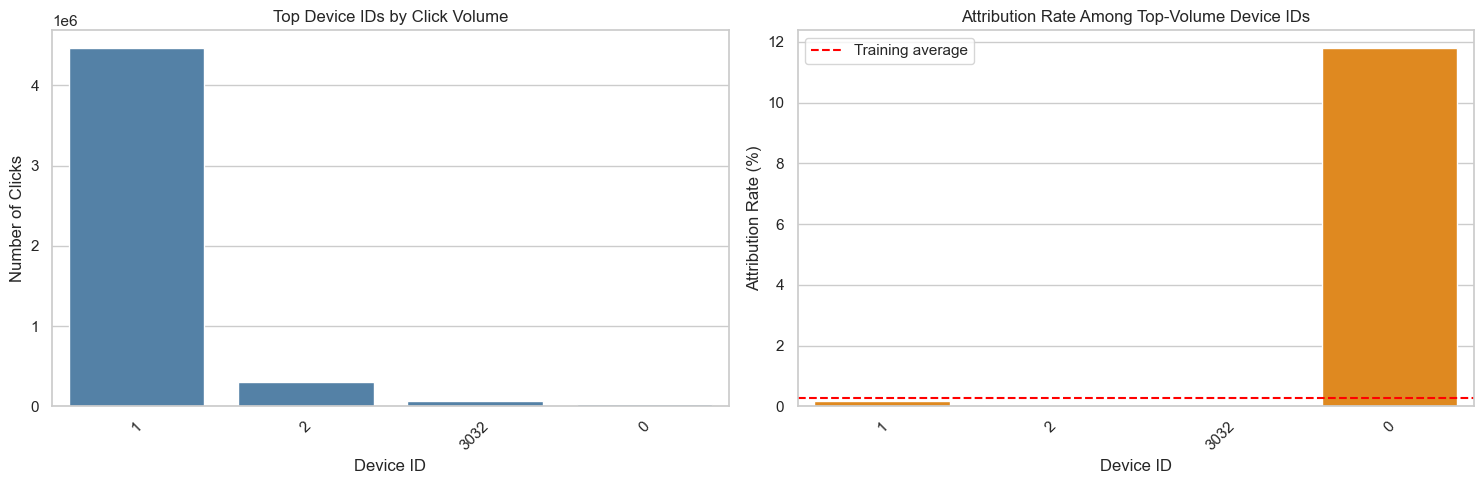

,device,clicks,attributed_clicks,attribution_rate
1,1,"4,461,958","7,317",0.1640%
2,2,"301,361",81,0.0269%
793,3032,"63,373",1,0.0016%
0,0,"29,560","3,485",11.7896%


In [17]:
device_summary = create_category_summary(train_df, "device")
top_devices = plot_top_categories(
    device_summary,
    "device",
    min_clicks=1_000,
)

display(
    top_devices[["device", "clicks", "attributed_clicks", "attribution_rate"]]
    .style.format({
        "clicks": "{:,.0f}",
        "attributed_clicks": "{:,.0f}",
        "attribution_rate": "{:.4f}%",
    })
)

**Insight:** Device traffic is highly concentrated. Always read the click count together with the rate. An unusual value such as device `0` may be an important encoded category, but its real-world meaning is unknown.

### Operating systems

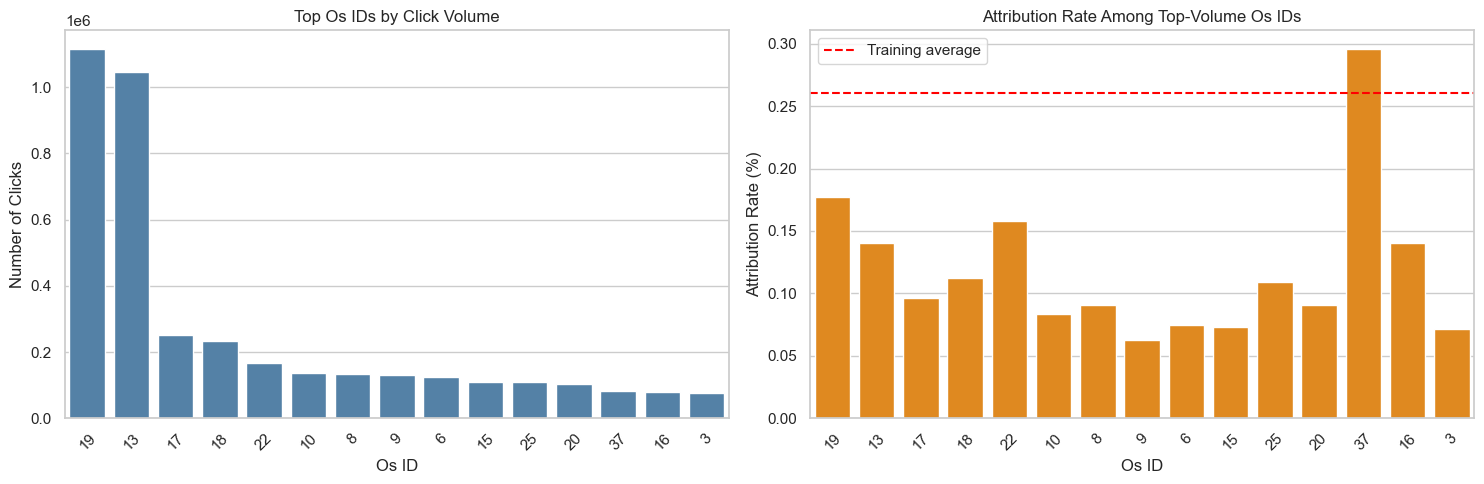

,os,clicks,attributed_clicks,attribution_rate
19,19,"1,115,684","1,978",0.1773%
13,13,"1,045,159","1,465",0.1402%
17,17,"251,932",242,0.0961%
18,18,"232,492",261,0.1123%
22,22,"168,147",266,0.1582%
10,10,"135,951",114,0.0839%
8,8,"134,441",122,0.0907%
9,9,"129,664",81,0.0625%
6,6,"124,330",93,0.0748%
15,15,"109,700",80,0.0729%


In [18]:
os_summary = create_category_summary(train_df, "os")
top_os = plot_top_categories(os_summary, "os", min_clicks=5_000)

display(
    top_os[["os", "clicks", "attributed_clicks", "attribution_rate"]]
    .style.format({
        "clicks": "{:,.0f}",
        "attributed_clicks": "{:,.0f}",
        "attribution_rate": "{:.4f}%",
    })
)

**Insight:** Popular operating systems can have different attribution rates. OS IDs are categories, so their numeric order has no meaning.

## 8. IP activity and traffic concentration

In [36]:
# clicks per IP Summary

ip_summary = (
    train_df.groupby("ip", observed=True)
    .agg(
        clicks=(TARGET, "size"),
        attributed_clicks=(TARGET, "sum"),
        unique_apps=("app", "nunique"),
        unique_channels=("channel", "nunique"),
    )
    .reset_index()
)

ip_summary["attribution_rate"] = (
    ip_summary["attributed_clicks"]
    / ip_summary["clicks"]
    * 100
)

display(
    ip_summary["clicks"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count    63208.000000
mean        76.985793
std        495.334591
min          1.000000
50%         27.000000
75%         72.000000
90%        145.000000
95%        246.000000
99%        724.930000
max      66418.000000
Name: clicks, dtype: float64

In [38]:
# top 10 Analysis for IP Address

sorted_ip = ip_summary.sort_values("clicks", ascending=False)

top_10_share = sorted_ip.head(10)["clicks"].sum() / sorted_ip["clicks"].sum() * 100

top_1_percent_count = max(1, int(len(sorted_ip) * 0.01))
top_1_percent_share = (
    sorted_ip.head(top_1_percent_count)["clicks"].sum()
    / sorted_ip["clicks"].sum()
    * 100
)

print(f"Top 10 IPs' share of clicks: {top_10_share:.2f}%")
print(f"Top 1% of IPs' share of clicks: {top_1_percent_share:.2f}%")

Top 10 IPs' share of clicks: 5.92%
Top 1% of IPs' share of clicks: 27.91%


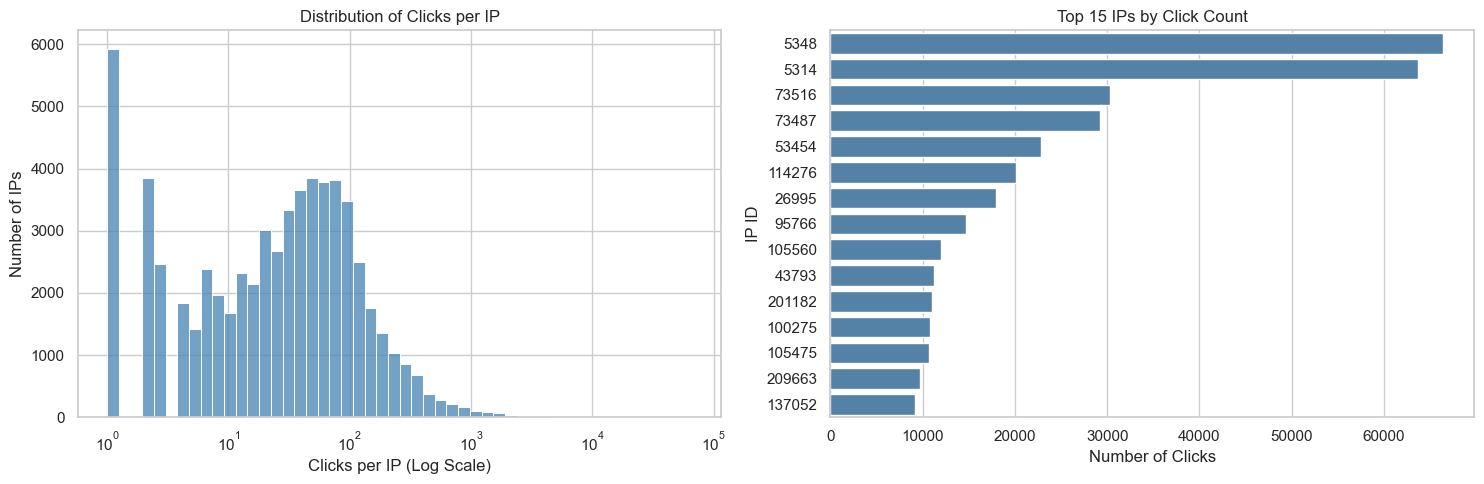

In [ ]:
# Clicks per IP histogram ---------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=ip_summary,
    x="clicks",
    bins=50,
    log_scale=(True, False),
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Distribution of Clicks per IP")
axes[0].set_xlabel("Clicks per IP (Log Scale)")
axes[0].set_ylabel("Number of IPs")

top_ip = sorted_ip.head(15).copy()
top_ip["ip"] = top_ip["ip"].astype(str)

# Top 15 IPs by click count --------------------

sns.barplot(
    data=top_ip,
    x="clicks",
    y="ip",
    color="steelblue",
    ax=axes[1],
)
axes[1].set_title("Top 15 IPs by Click Count")
axes[1].set_xlabel("Number of Clicks")
axes[1].set_ylabel("IP ID")

plt.tight_layout()
plt.show()

**Insight:** IP activity is uneven. High click frequency and wide app or channel activity may help the model, but high activity alone does not prove fraud.

## 9. Repeated-click behaviour

In [ ]:
# Investigate repeated click combinations

# Group by combinations:
# ip + app
# ip + app + device + os
# ip + app + device + os + channel

def repetition_summary(data, features):
    counts = data.groupby(features, observed=True, sort=False).size()

    result = {
        "combination": " + ".join(features),
        "unique_combinations": len(counts),
        "median_clicks": counts.median(),
        "90th_percentile": counts.quantile(0.90),
        "95th_percentile": counts.quantile(0.95),
        "99th_percentile": counts.quantile(0.99),
        "maximum_clicks": counts.max(),
    }

    return result


repetition_results = pd.DataFrame([
    repetition_summary(
        train_df, 
        ["ip", "app"]
    ),
    repetition_summary(
        train_df, 
        ["ip", "app", "device", "os"]
    ),
    repetition_summary(
        train_df,
        ["ip", "app", "device", "os", "channel"],
    ),
])

display(repetition_results.style.format({
    "unique_combinations": "{:,.0f}",
    "median_clicks": "{:,.0f}",
    "90th_percentile": "{:,.0f}",
    "95th_percentile": "{:,.0f}",
    "99th_percentile": "{:,.0f}",
    "maximum_clicks": "{:,.0f}",
}))

,combination,unique_combinations,median_clicks,90th_percentile,95th_percentile,99th_percentile,maximum_clicks
0,ip + app,"714,912",2,13,21,62,"10,268"
1,ip + app + device + os,"1,946,077",1,4,7,18,"2,318"
2,ip + app + device + os + channel,"2,970,922",1,2,4,10,979


**Insight:** Repetition becomes lower when more fields are included. Extreme repetition may be useful as a behavioural feature, but an IP is not the same as one person and repetition does not prove automation.

## 10. App and channel interaction

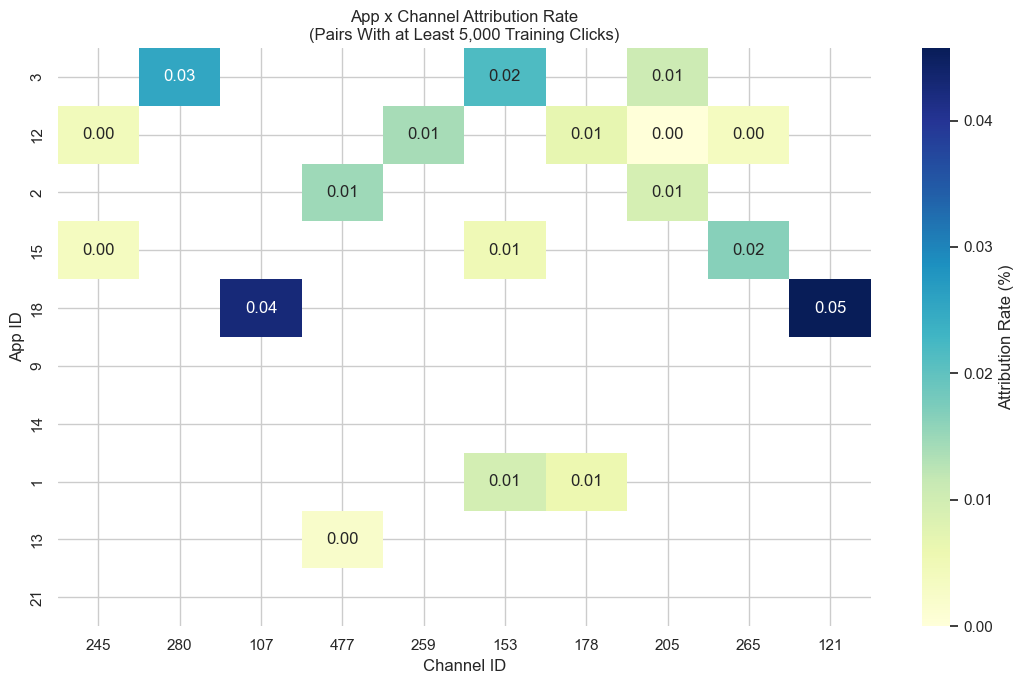

In [ ]:
# Interaction Examination ------------------

MIN_PAIR_CLICKS = 5_000

app_channel_summary = (
    train_df.groupby(["app", "channel"], observed=True)
    .agg(
        clicks=(TARGET, "size"),
        attribution_rate=(TARGET, "mean"),
    )
    .reset_index()
)

app_channel_summary["attribution_rate"] *= 100

supported_pairs = app_channel_summary.loc[
    app_channel_summary["clicks"] >= MIN_PAIR_CLICKS
].copy()

# Heat Map -------------------------

top_app_ids = train_df["app"].value_counts().head(10).index
top_channel_ids = train_df["channel"].value_counts().head(10).index

heatmap_data = supported_pairs.loc[
    supported_pairs["app"].isin(top_app_ids)
    & supported_pairs["channel"].isin(top_channel_ids)
]

rate_matrix = (
    heatmap_data.pivot(
        index="app",
        columns="channel",
        values="attribution_rate",
    )
    .reindex(index=top_app_ids, columns=top_channel_ids)
)

plt.figure(figsize=(11, 7))
sns.heatmap(
    rate_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    mask=rate_matrix.isna(),
    cbar_kws={"label": "Attribution Rate (%)"},
)

plt.title(
    "App x Channel Attribution Rate\n"
    f"(Pairs With at Least {MIN_PAIR_CLICKS:,} Training Clicks)"
)
plt.xlabel("Channel ID")
plt.ylabel("App ID")
plt.tight_layout()
plt.show()

**Insight:** The same app can perform differently across channels. Blank cells did not meet the 5,000-click requirement. This interaction may be useful during feature engineering.

## 11. Unseen categories in validation

In [ ]:

unseen_results = []

for column in CATEGORICAL_COLUMNS:
    train_categories = set(train_df[column].unique())
    unseen_mask = ~validation_df[column].isin(train_categories)

    unseen_count = validation_df.loc[unseen_mask, column].nunique()
    validation_unique = validation_df[column].nunique()

    unseen_results.append({
        "feature": column,
        "unseen_categories": unseen_count,
        "validation_unique_categories": validation_unique,
        "unseen_category_percentage": unseen_count / validation_unique * 100,
        "validation_rows_affected": int(unseen_mask.sum()),
        "affected_row_percentage": unseen_mask.mean() * 100,
    })

unseen_summary = pd.DataFrame(unseen_results)

display(unseen_summary.style.format({
    "unseen_categories": "{:,.0f}",
    "validation_unique_categories": "{:,.0f}",
    "unseen_category_percentage": "{:.2f}%",
    "validation_rows_affected": "{:,.0f}",
    "affected_row_percentage": "{:.4f}%",
}))

,feature,unseen_categories,validation_unique_categories,unseen_category_percentage,validation_rows_affected,affected_row_percentage
0,ip,"3,769","48,094",7.84%,"15,245",0.9958%
1,app,12,259,4.63%,21,0.0014%
2,device,108,449,24.05%,154,0.0101%
3,os,19,195,9.74%,45,0.0029%
4,channel,2,163,1.23%,2,0.0001%


**Insight:** New category IDs appear in later data. The affected-row percentage shows their real impact. Future encoders must handle unknown values safely.

## 12. Final EDA findings

- The target is extremely imbalanced: only about 0.25% of clicks are attributed.
- Attribution behaviour changes over time, so validation must remain chronological.
- `ip` has very high cardinality and click activity is concentrated.
- Apps, channels, devices and operating systems show different attribution patterns.
- Rates must always be checked together with click counts.
- Repeated-click counts and app-channel combinations may be useful features.
- New IDs appear in validation, so unknown categories must be handled safely.
- `attributed_time` must never be used as a model feature.

## 13. Feature ideas for the next stage

- hour and minute from `click_time`;
- earlier click count for the same IP;
- earlier counts for IP-app and IP-channel combinations;
- number of apps or channels previously seen for an IP;
- time since the previous similar click;
- app-channel and device-OS interactions.

> All behavioural features must use only information available at or before the click. Frequency mappings must be learned from training data, not from validation data.

## 14. Limitation

This development dataset covers only two hours on one day. Its patterns are useful for development, but they must be checked again on a longer time period before making final claims.